# Análisis de Dataset y Modelo de Árbol de Decisión
### By Sergio
Este notebook realiza:
- Limpieza de datos (nulos, espacios en blanco)
- Análisis descriptivo
- Estimación de diagnósticos por paciente
- Modelo de Árbol de Decisión
- Modelo de Random Forest
- Evaluación: accuracy, precision, recall, F1-score


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

## Cargar Dataset

In [4]:
df = pd.read_csv('dataset_elpino.csv', sep=';') # Trying semicolon as delimiter
# If still error, try other delimiters like '\t' for tab or inspect the file for the correct one.
df.head()

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
3,K76.8 - Otras enfermedades especificadas del h...,K66.1 - Hemoperitoneo,"N18.5 - Enfermedad renal crónica, estadio 5",D64.9 - Anemia de tipo no especificado,E87.5 - Hiperpotasemia,E87.2 - Acidosis,J81 - Edema pulmonar,N17.8 - Otras insuficiencias renales agudas,J44.9 - Enfermedad pulmonar obstructiva crónic...,R41.0 - Desorientación no especificada,...,57.94 - SONDAJE URINARIO PERMANENTE,00.13 - INYECCION NESIRITIDE,00.17 - INFUSON AGENTE VASOPRESOR,99.04 - TRANSFUSION CONCENTRADO HEMATIES,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.23 - INYECCION ESTEROIDE,61,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
4,T81.0 - Hemorragia y hematoma que complican un...,"Y83.2 - Operación quirúrgica con anastomosis, ...",S31.1 - Herida de la pared abdominal,S36.80 - Traumatismo de otros órganos intraabd...,W31.62 - Contacto traumático con otras maquina...,"J96.09 - Insuficiencia respiratoria aguda, Tip...",J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,"U07.1 - COVID-19, virus identificado","N39.0 - Infección de vías urinarias, sitio no ...",...,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,93.

## Limpieza de Datos

In [7]:
# Eliminar espacios en blanco en strings
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Reemplazar strings vacíos por NaN
df.replace('', np.nan, inplace=True)

# Eliminar filas completamente nulas
df.dropna(how='all', inplace=True)

# Rellenar valores nulos simples
df.fillna(method='ffill', inplace=True)

df.info()

/tmp/ipykernel_82683/2771648760.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8917 entries, 0 to 8916
Data columns (total 68 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Diag 01 Principal (cod+des)     8917 non-null   object
 1   Diag 02 Secundario (cod+des)    8917 non-null   object
 2   Diag 03 Secundario (cod+des)    8917 non-null   object
 3   Diag 04 Secundario (cod+des)    8917 non-null   object
 4   Diag 05 Secundario (cod+des)    8917 non-null   object
 5   Diag 06 Secundario (cod+des)    8917 non-null   object
 6   Diag 07 Secundario (cod+des)    8917 non-null   object
 7   Diag 08 Secundario (cod+des)    8917 non-null   object
 8   Diag 09 Secundario (cod+des)    8917 non-null   object
 9   Diag 10 Secundario (cod+des)    8917 non-null   object
 10  Diag 11 Secundario (cod+des)    8917 non-null   object
 11  Diag 12 Secundario (cod+des)    8917 non-null   object
 12  Diag 13 Secundario (cod+des)    8917 non-null   

/tmp/ipykernel_82683/2771648760.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


## Análisis Descriptivo

In [8]:
df.describe(include='all')

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
count,8917,8917,8917,8917,8917,8917,8917,8917,8917,8917,...,8917,8917,8917,8917,8917,8917,8917,8917.000000,8917,8917
unique,1221,1369,1187,1031,878,775,661,584,519,484,...,102,102,97,93,87,84,85,NaN,2,485
top,O70.0 - Desgarro perineal de primer grado dura...,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,NaN,Mujer,146101 - PH CESÁREA
freq,479,761,1626,2482,3252,3890,4505,5209,5901,6474,...,7705,7814,7898,7992,8065,8143,8218,NaN,5910,475
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.167433,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.188301,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.000000,NaN,NaN


## Estimación de Diagnósticos por Paciente

In [9]:
# Identificar todas las columnas de diagnóstico
diag_columns = [f'Diag {i:02d} Secundario (cod+des)' for i in range(2, 36)]
diag_columns.insert(0, 'Diag 01 Principal (cod+des)')

# Contar el número de diagnósticos válidos (no '-') por cada registro (paciente/visita)
df['num_diagnoses'] = df[diag_columns].apply(lambda row: (row != '-').sum(), axis=1)

# Mostrar el análisis descriptivo del número de diagnósticos por paciente
display(df['num_diagnoses'].describe())

,num_diagnoses
count,8917.000000
mean,7.308288
std,5.411090
min,1.000000
25%,3.000000
50%,6.000000
75%,10.000000
max,35.000000


## Preparación de Datos para ML

In [10]:
# Codificación de variables categóricas
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Definir X e y (ajustar 'target' si es necesario)
target = df_encoded.columns[-1]
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modelo Árbol de Decisión

In [11]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Evaluación del Modelo

In [12]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.9966367713004485
Precision: 0.9961965336519581
Recall: 0.9966367713004485
F1 Score: 0.9963267403378819


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Análisis de Importancia de Características (Feature Importance)
El `feature_importances_` del modelo nos indica la relevancia de cada característica para la toma de decisiones del árbol. Vamos a visualizarlas.

,feature,importance
3,Diag 04 Secundario (cod+des),0.099560
1,Diag 02 Secundario (cod+des),0.097342
2,Diag 03 Secundario (cod+des),0.092715
4,Diag 05 Secundario (cod+des),0.090054
6,Diag 07 Secundario (cod+des),0.077484
8,Diag 09 Secundario (cod+des),0.075834
5,Diag 06 Secundario (cod+des),0.072463
7,Diag 08 Secundario (cod+des),0.071289
9,Diag 10 Secundario (cod+des),0.063540
10,Diag 11 Secundario (cod+des),0.056671


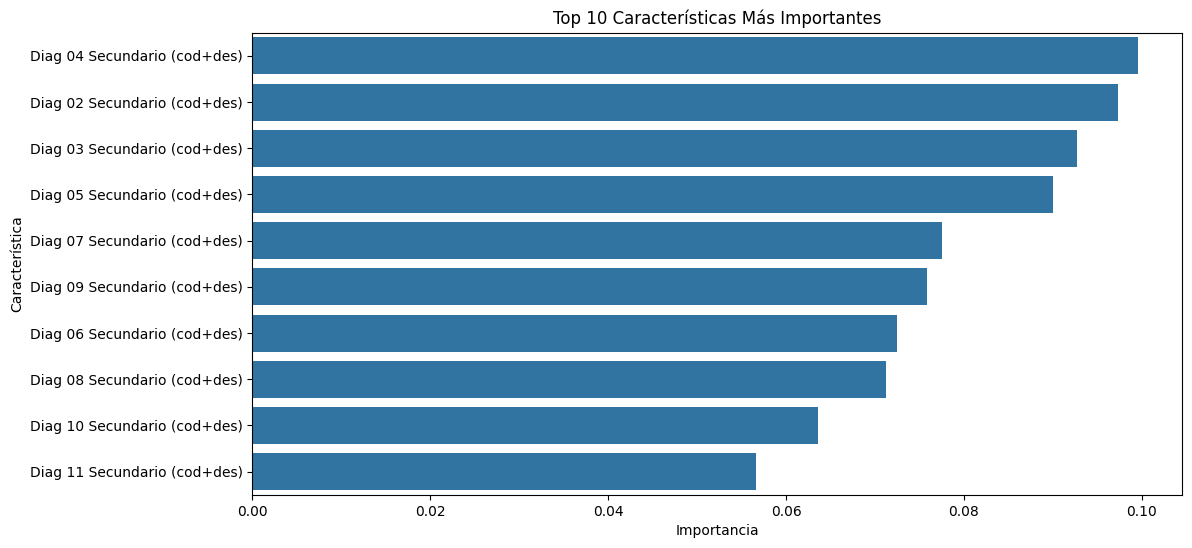

In [13]:
import seaborn as sns

feature_importances = pd.DataFrame({'feature': X_train.columns, 'importance': model.feature_importances_})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

display(feature_importances.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importances.head(10))
plt.title('Top 10 Características Más Importantes')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

## Modelo Random Forest

Vamos a implementar un modelo de Random Forest para comparar su rendimiento con el Árbol de Decisión.

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar y entrenar el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

## Evaluación del Modelo Random Forest

In [15]:
print('--- Evaluación Random Forest ---')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Precision:', precision_score(y_test, y_pred_rf, average='weighted', zero_division=0))
print('Recall:', recall_score(y_test, y_pred_rf, average='weighted', zero_division=0))
print('F1 Score:', f1_score(y_test, y_pred_rf, average='weighted', zero_division=0))

--- Evaluación Random Forest ---
Accuracy: 0.9971973094170403
Precision: 0.9965594814158848
Recall: 0.9971973094170403
F1 Score: 0.9966750421752932
